# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [5]:
os.makedirs('./data', exist_ok=True)
!kaggle datasets download -d dgomonov/new-york-city-airbnb-open-data -p ./data

with zipfile.ZipFile('./data/new-york-city-airbnb-open-data.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')

Dataset URL: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data
License(s): CC0-1.0




  0%|          | 0.00/2.44M [00:00<?, ?B/s]
 41%|████      | 1.00M/2.44M [00:00<00:00, 1.63MB/s]
 82%|████████▏ | 2.00M/2.44M [00:00<00:00, 2.95MB/s]
100%|██████████| 2.44M/2.44M [00:00<00:00, 2.96MB/s]


In [31]:
df = pd.read_csv('./data/AB_NYC_2019.csv')
print("Данные успешно загружены!")
print(f"Размер датасета: {df.shape}")
drop_columns = ['id', 'name', 'host_id', 'host_name', 'last_review']
df = df.drop(drop_columns, axis=1)
df_1 = df.copy()
df_1.info()

Данные успешно загружены!
Размер датасета: (48895, 16)
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), str(3)
memory usage: 4.1

In [32]:
df_1.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


## Анализируем данные и смотрим разбросы

In [33]:
df_1.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
10%,40.667990,-73.996690,49.000000,1.000000,0.000000,0.060000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
90%,40.804890,-73.907810,269.000000,28.000000,70.000000,3.630000,5.000000,337.000000
95%,40.825643,-73.865771,355.000000,30.000000,114.000000,4.640000,15.000000,359.000000


In [34]:
df_1['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [35]:
df_1['neighbourhood'].value_counts()

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
                      ... 
Richmondtown             1
Fort Wadsworth           1
New Dorp                 1
Rossville                1
Willowbrook              1
Name: count, Length: 221, dtype: int64

In [36]:
df_1['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

## Смотрим пропуски

In [37]:
df_1.isnull().sum()

neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## Готовим предварительные данные и анализируем корреляции

In [38]:
# устраняем пропуски
df_1['reviews_per_month'] = df_1['reviews_per_month'].fillna(0)

# разворачиваем категориальные признаки
columns_str = df_1.select_dtypes(include=['str']).columns

df_1 = pd.get_dummies(df_1, columns=columns_str.tolist())

df_1.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,...,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,False,True,...,False,False,False,False,False,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,False,...,False,False,False,False,False,False,False,True,False,False
2,40.80902,-73.94190,150,3,0,0.00,1,365,False,False,...,False,False,False,False,False,False,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,False,True,...,False,False,False,False,False,False,False,True,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,False,...,False,False,False,False,False,False,False,True,False,False


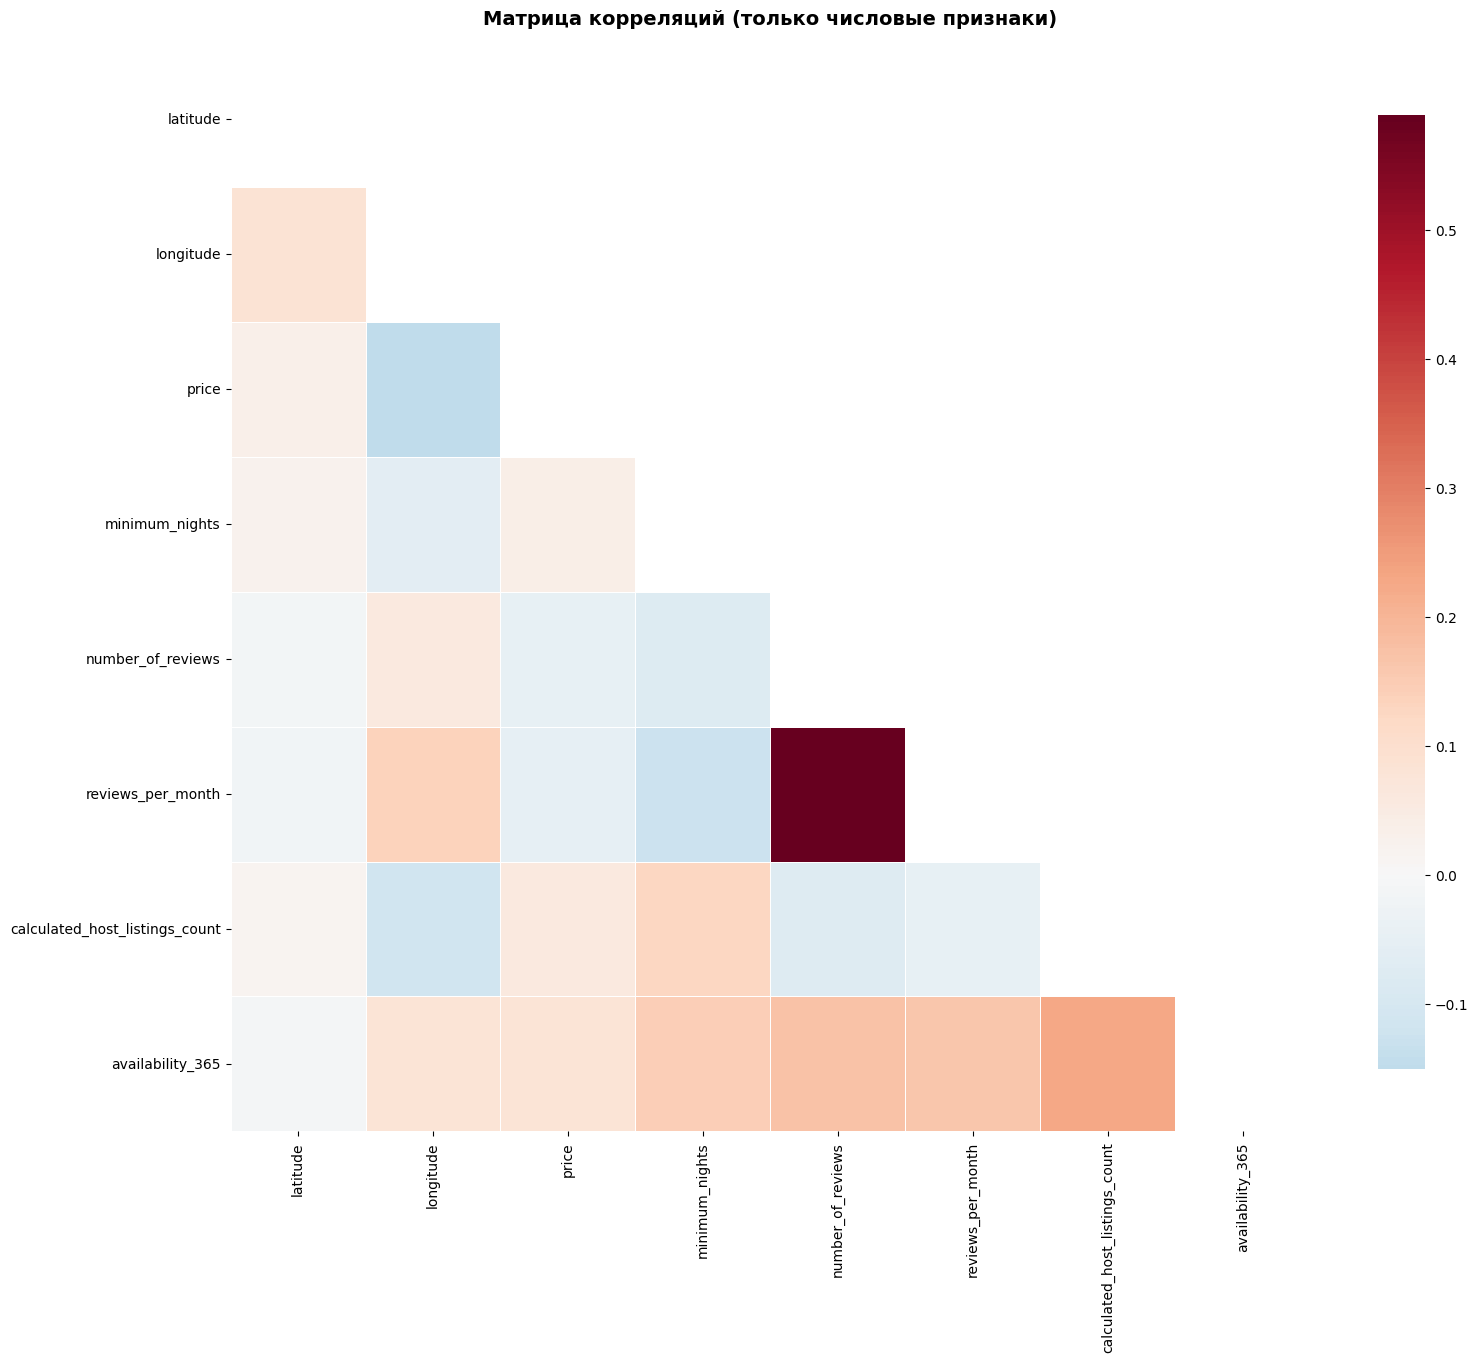

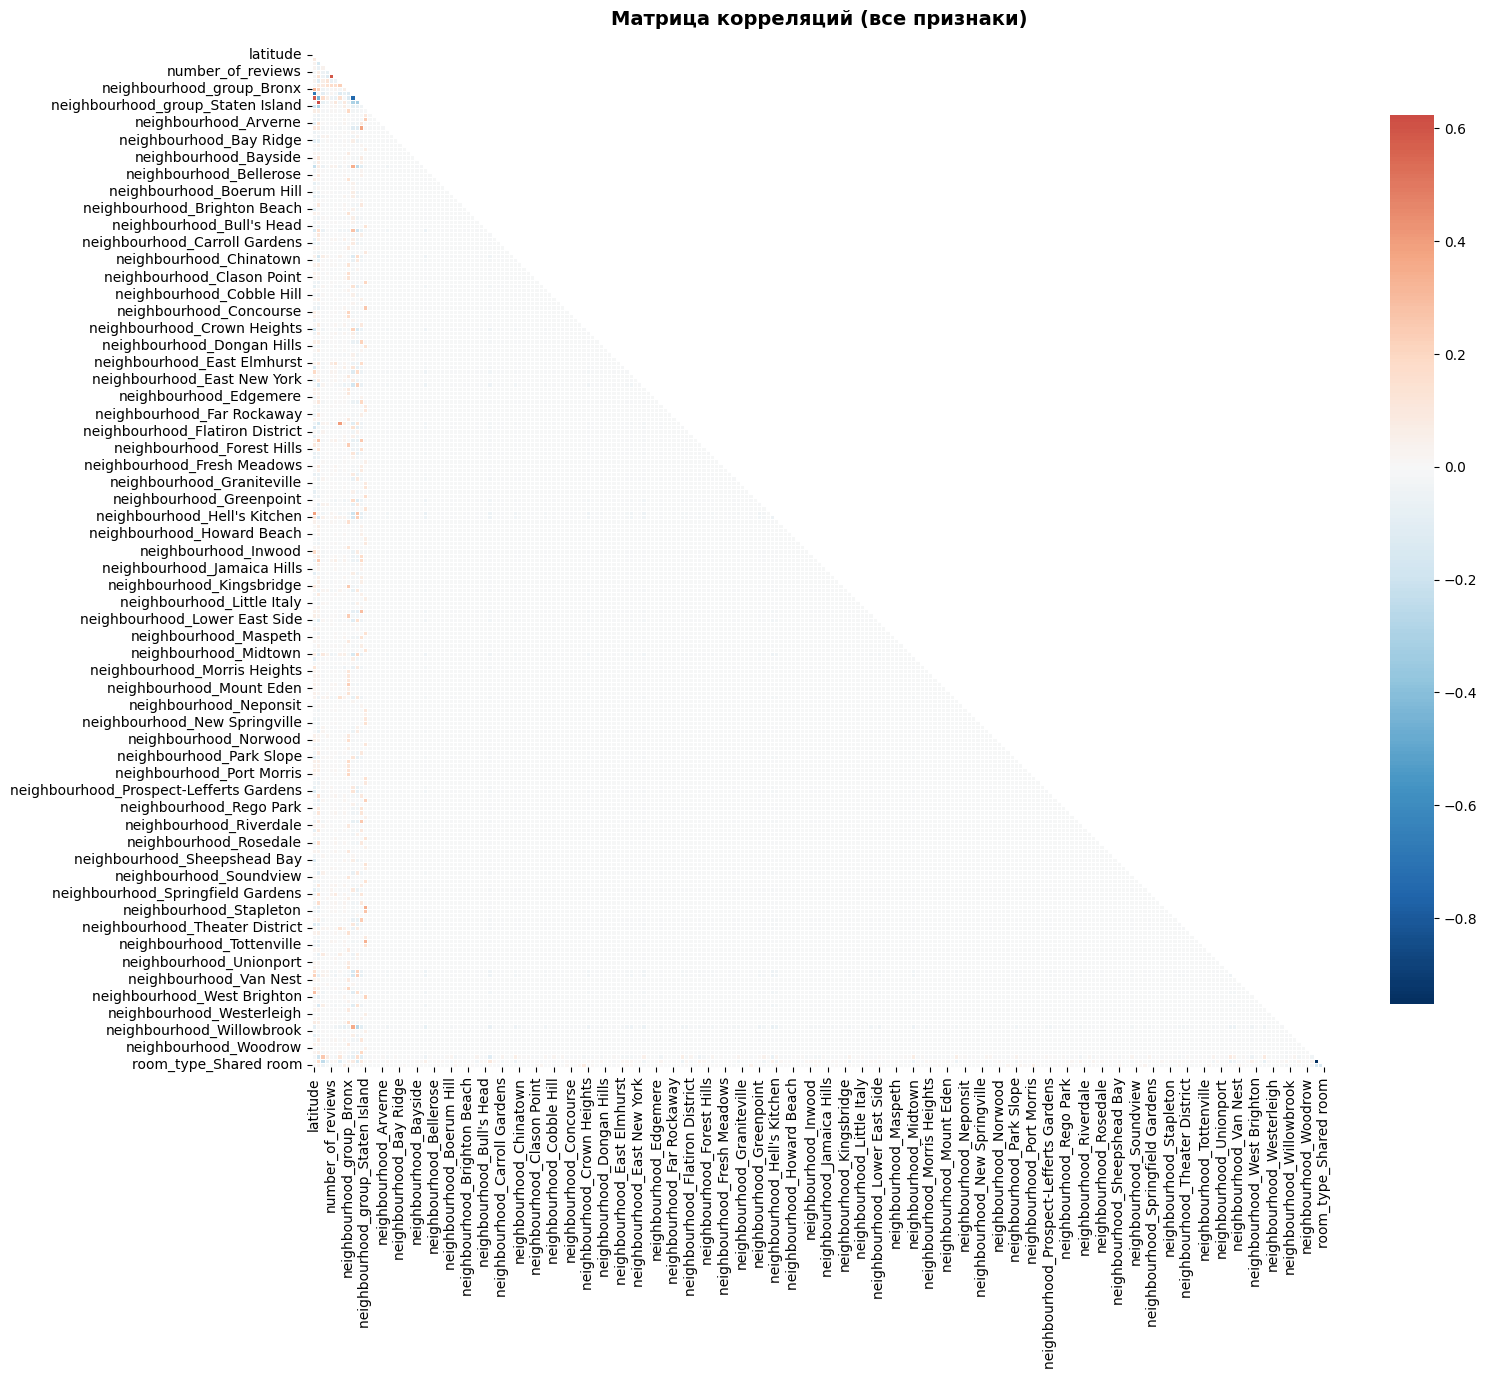

In [39]:
def draw_matrix_corr(corr_matrix, features_text = ""):
    # Создаем маску для верхнего треугольника (чтобы не дублировать)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Большая тепловая карта
    plt.figure(figsize=(16, 14))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', 
                center=0, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title(f'Матрица корреляций {features_text}', 
            fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()


# корреляция только по числовым признакам
draw_matrix_corr(df_1.select_dtypes(include=[np.number]).corr(), "(только числовые признаки)")

# Считаем корреляцию
corr_matrix = df_1.corr()

draw_matrix_corr(corr_matrix, "(все признаки)")



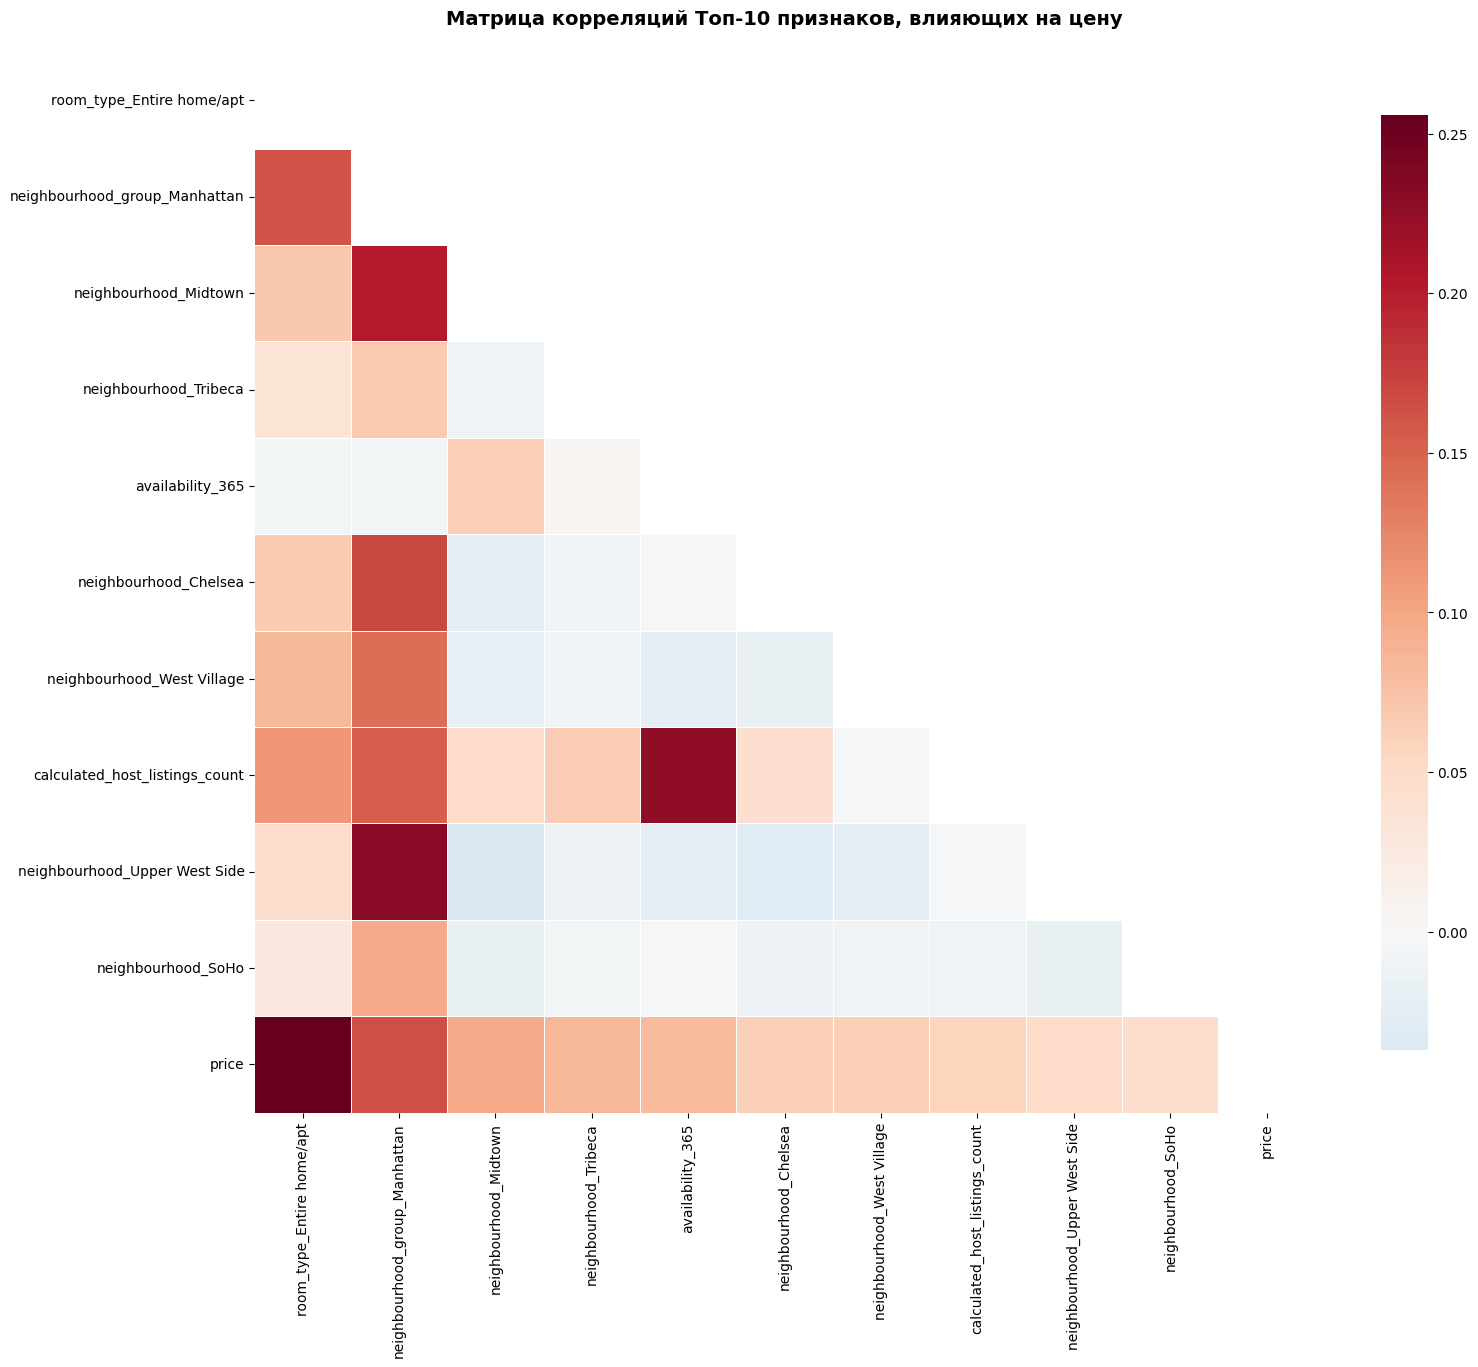

Топ-10 признаков по влиянию на цену:
room_type_Entire home/apt         0.255857
neighbourhood_group_Manhattan     0.163976
neighbourhood_Midtown             0.097781
neighbourhood_Tribeca             0.084814
availability_365                  0.081829
neighbourhood_Chelsea             0.061657
neighbourhood_West Village        0.060472
calculated_host_listings_count    0.057472
neighbourhood_Upper West Side     0.049667
neighbourhood_SoHo                0.048058
Name: price, dtype: float64


In [40]:
# Смотрим, как все признаки влияют на цену
price_corr = df_1.corr()['price'].drop('price').sort_values(ascending=False)

# Берем топ-10 признаков с самой сильной корреляцией
top_features = price_corr.head(10).index.tolist()
top_features_with_price = top_features + ['price']


draw_matrix_corr(df_1[top_features_with_price].corr(), "Топ-10 признаков, влияющих на цену")

# plt.figure(figsize=(10, 8))
# sns.heatmap(df_dummy[top_features_with_price].corr(), 
#             annot=True, fmt='.2f', cmap='RdBu_r', center=0,
#             square=True, linewidths=0.5)
# plt.title('Топ-10 признаков, влияющих на цену', fontweight='bold')
# plt.tight_layout()
# plt.show()

print("Топ-10 признаков по влиянию на цену:")
print(price_corr.head(10))

## Убираем явные аномалии для лучшего качества

In [41]:
# Убираем явные аномалии для лучшего качества моделей
df_1 = df_1[df_1['price'] < 800].copy() # 800 потому что 99 персентиль 799
df_1 = df_1[df_1['minimum_nights'] <= 45].copy() # 45 потому что персентиль 99 = 45

# Логарифмируем целевую переменную (цену)
df_1['price_log'] = np.log1p(df_1['price'])

df_1.describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_log
count,47975.000000,47975.000000,47975.000000,47975.000000,47975.000000,47975.000000,47975.000000,47975.000000,47975.000000
mean,40.728844,-73.951816,137.604794,5.738843,23.543575,1.104889,7.175571,111.494132,4.712822
std,0.054616,0.046250,103.912069,8.448650,44.804609,1.605603,33.104954,131.005978,0.651195
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
10%,40.667840,-73.996426,49.000000,1.000000,0.000000,0.000000,1.000000,0.000000,3.912023
25%,40.689920,-73.982770,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000,4.248495
50%,40.722810,-73.955410,105.000000,2.000000,5.000000,0.380000,1.000000,43.000000,4.663439
75%,40.763150,-73.935800,175.000000,5.000000,24.000000,1.620000,2.000000,222.000000,5.170484
90%,40.805040,-73.907504,250.000000,21.000000,71.000000,3.270000,5.000000,336.000000,5.525453
95%,40.825703,-73.864962,345.000000,30.000000,115.000000,4.340000,15.000000,358.000000,5.846439


## Готовим данные для тренировки и для теста, логарифмируем цену

In [ ]:
# Целевая переменная - логарифмированная цена
y_2 = df_1['price_log']

# Признаки - всё кроме price и price_log
X_2 = df_1.drop(['price', 'price_log'], axis=1)

# Разделяем на train/test
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_2, y_2, test_size=0.3, random_state=42
)

print(f"Обучающая выборка: {X_train_1.shape}")
print(f"Тестовая выборка: {X_test_1.shape}")
print(f"\nЦелевая переменная (price_log):")
print(f"  Среднее: {y_train_1.mean():.3f}")
print(f"  Стандартное отклонение: {y_train_1.std():.3f}")

Обучающая выборка: (33582, 236)
Тестовая выборка: (14393, 236)

Целевая переменная (price_log):
  Среднее: 4.713
  Стандартное отклонение: 0.650


## Масштабируем признаки

In [44]:
# Масштабируем признаки
scaler_1 = StandardScaler()
X_train_scaled = scaler_1.fit_transform(X_train_1)
X_test_scaled = scaler_1.transform(X_test_1)

In [121]:
def train_and_check_by_models(X_train_scaled, y_train, X_test_scaled, y_test):
    # Создаем модели
    models = {
        'Linear Regression': LinearRegression(),
        'RidgeCV': RidgeCV(cv=5),
        'LassoCV': LassoCV(cv=5, random_state=42, max_iter=10000),
        'ElasticNetCV': ElasticNetCV(cv=5, random_state=42, max_iter=10000, l1_ratio=[.1, .5, .7, .9, .95, .99, 1])
    }

    # Словари для результатов
    results = {}
    predictions = {}
    params_info = {}

    # Обучаем
    for name, model in models.items():
        print(f"Обучение {name}...")
        model.fit(X_train_scaled, y_train)
        
        # Предсказания на тестовых данных
        y_pred_test = model.predict(X_test_scaled)
        predictions[name] = y_pred_test
        
        # Предсказания на обучающих данных
        y_pred_train = model.predict(X_train_scaled)
        
        # Метрики для TRAIN (на оригинальной шкале цен)
        y_train_original = np.expm1(y_train)
        y_pred_train_original = np.expm1(y_pred_train)
        
        r2_train = r2_score(y_train, y_pred_train)
        rmse_train = np.sqrt(mean_squared_error(y_train_original, y_pred_train_original))
        mae_train = mean_absolute_error(y_train_original, y_pred_train_original)
        
        # Метрики для TEST (на оригинальной шкале цен)
        y_test_original = np.expm1(y_test)
        y_pred_test_original = np.expm1(y_pred_test)
        
        r2_test = r2_score(y_test, y_pred_test)
        rmse_test = np.sqrt(mean_squared_error(y_test_original, y_pred_test_original))
        mae_test = mean_absolute_error(y_test_original, y_pred_test_original)

        # Статистика по предсказаниям для TEST
        y_pred_test_orig = np.expm1(y_pred_test)
        
        results[name] = {
            # Метрики для TRAIN
            'Train R²': r2_train,
            'Train RMSE ($)': rmse_train,
            'Train MAE ($)': mae_train,
            
            # Метрики для TEST
            'Test R²': r2_test,
            'Test RMSE ($)': rmse_test,
            'Test MAE ($)': mae_test,
            
            # Статистика предсказаний на TEST
            'Test min_pred': round(y_pred_test_orig.min(), 2),
            'Test max_pred': round(y_pred_test_orig.max(), 2),
            'Test mean_pred': round(y_pred_test_orig.mean(), 2),
            'Test std_pred': round(y_pred_test_orig.std(), 2)
        }
        
        # Собираем информацию о параметрах
        params = {}
        if hasattr(model, 'alpha_'):
            params['alpha'] = model.alpha_
        if hasattr(model, 'l1_ratio_') and model.l1_ratio_ is not None:
            params['l1_ratio'] = model.l1_ratio_
        params_info[name] = params

    # Создаем DataFrame с результатами
    results_df = pd.DataFrame(results).T
    
    # Добавляем информацию о параметрах
    for name in results_df.index:
        if name in params_info:
            if 'alpha' in params_info[name]:
                results_df.loc[name, 'alpha'] = params_info[name]['alpha']
            if 'l1_ratio' in params_info[name]:
                results_df.loc[name, 'l1_ratio'] = params_info[name]['l1_ratio']
    
    # Переставляем колонки для удобства
    column_order = ['Train R²', 'Train RMSE ($)', 'Train MAE ($)',
                    'Test R²', 'Test RMSE ($)', 'Test MAE ($)',
                    'Test min_pred', 'Test max_pred', 'Test mean_pred', 'Test std_pred',
                    'alpha', 'l1_ratio']
    
    # Добавляем только существующие колонки
    existing_cols = [col for col in column_order if col in results_df.columns]
    results_df = results_df[existing_cols]
    
    return models, results_df, predictions

## Пробуем на имеющихся признаках (без добавления новых)

In [122]:
# Пробуем на имеющихся фичах (без добавления новых)
models_1, results_df_1, predictions_1  = train_and_check_by_models(X_train_scaled, y_train_1, X_test_scaled, y_test_1)

for name, pred in predictions_1.items():
    print(f"\n{name} - предсказания (первые 10): {np.round(pred[:5], 2)}")

results_df_1


Обучение Linear Regression...
Обучение RidgeCV...
Обучение LassoCV...
Обучение ElasticNetCV...

Linear Regression - предсказания (первые 10): [5.4  5.15 4.42 3.94 4.4 ]

RidgeCV - предсказания (первые 10): [5.4  5.15 4.42 3.94 4.4 ]

LassoCV - предсказания (первые 10): [5.4  5.15 4.41 3.93 4.39]

ElasticNetCV - предсказания (первые 10): [5.4  5.15 4.41 3.93 4.39]


,Train R²,Train RMSE ($),Train MAE ($),Test R²,Test RMSE ($),Test MAE ($),Test min_pred,Test max_pred,Test mean_pred,Test std_pred,alpha,l1_ratio
Linear Regression,0.592429,79.441011,45.236651,0.583548,81.850304,46.330010,23.43,411.93,124.04,61.48,NaN,NaN
RidgeCV,0.592429,79.442265,45.236536,0.583573,81.850850,46.328385,23.46,411.69,124.03,61.46,10.000000,NaN
LassoCV,0.591960,79.528427,45.245999,0.584190,81.891306,46.288525,24.38,403.16,123.82,60.91,0.000678,NaN
ElasticNetCV,0.591960,79.528427,45.245999,0.584190,81.891306,46.288525,24.38,403.16,123.82,60.91,0.000678,1.0


## Добавляем новые признаки

In [124]:
# добавляем новые признаки

df_2 = df.copy()

# устраняем пропуски
df_2['reviews_per_month'] = df_2['reviews_per_month'].fillna(0)

# Убираем явные аномалии для лучшего качества моделей
df_2 = df_2[df_2['price'] < 800].copy() # 800 потому что 99 персентиль 799
df_2 = df_2[df_2['minimum_nights'] <= 45].copy() # 45 потому что персентиль 99 = 45



# Расстояние до центра Манхэттена
manhattan_center = (40.7580, -73.9855)
dist_manhattan = np.sqrt(
    (df_2['latitude'] - manhattan_center[0])**2  + 
    (df_2['longitude'] - manhattan_center[1])**2
)
df_2['dist_manhattan'] = np.log1p(dist_manhattan * 10)

# Расстояние до центра Бруклина
brooklyn_center = (40.6782, -73.9442)
dist_brooklyn = np.sqrt(
    (df_2['latitude'] - brooklyn_center[0])**2 + 
    (df_2['longitude'] - brooklyn_center[1])**2
)
df_2['dist_brooklyn'] = np.log1p(dist_brooklyn * 10)

df_2['popularity'] = df_2['number_of_reviews'] * df_2['availability_365'] / 1000


# Кластерные средние
from sklearn.cluster import KMeans
coords = df_2[['latitude', 'longitude']].values
kmeans = KMeans(n_clusters=20, random_state=42)
df_2['geo_cluster'] = kmeans.fit_predict(coords)

print(df_2['neighbourhood_group'].value_counts())

# plt.figure(figsize=(10, 8))
# sns.heatmap(df_dummy[top_features_with_price].corr(), 
#             annot=True, fmt='.2f', cmap='RdBu_r', center=0,
#             square=True, linewidths=0.5)
# plt.title('Топ-10 признаков, влияющих на цену', fontweight='bold')
# plt.tight_layout()
# plt.show()


# Разделяем на train/test
df_2_train, df_2_test = train_test_split(df_2, test_size=0.3, random_state=42)

# Считаем статистику только на train
train_avg_price = df_2_train.groupby('neighbourhood')['price'].mean()
train_density = df_2_train['neighbourhood'].value_counts()

# Запоминаем средние значения для заполнения пропусков
avg_price_fill = train_avg_price.mean()
density_fill = train_density.mean()

# Применяем к train
# Плотность объявлений в микрорайоне (сколько всего объявлений в этом микрорайоне)
df_2_train['neighbourhood_density'] = df_2_train['neighbourhood'].map(train_density).fillna(density_fill)

# Средняя цена в микрорайоне
# df_2_train['neighbourhood_avg_price'] = df_2_train['neighbourhood'].map(train_avg_price).fillna(avg_price_fill)

# Применяем к test (используем статистику из train!)
# df_2_test['neighbourhood_avg_price'] = df_2_test['neighbourhood'].map(train_avg_price).fillna(avg_price_fill)
df_2_test['neighbourhood_density'] = df_2_test['neighbourhood'].map(train_density).fillna(density_fill)

cluster_avg = df_2_train.groupby('geo_cluster')['price'].mean()
df_2_train['cluster_avg_price'] = df_2_train['geo_cluster'].map(cluster_avg)
df_2_test['cluster_avg_price'] = df_2_test['geo_cluster'].map(cluster_avg).fillna(df_2_train['price'].mean())

# Отклонение от средней (с проверкой деления на 0)
# for dataset in [df_2_train, df_2_test]:
#     # Защита от деления на 0
#     dataset['price_vs_neighbourhood'] = dataset['price'] / dataset['neighbourhood_avg_price'].clip(lower=0.01)
#     # Проверка на NaN после деления
#     if dataset['price_vs_neighbourhood'].isnull().any():
#         dataset['price_vs_neighbourhood'] = dataset['price_vs_neighbourhood'].fillna(1.0)

# кодируем категории (отдельно для train и test)
for dataset in [df_2_train, df_2_test]:
    columns_str = dataset.select_dtypes(include=['str']).columns
    dataset_encoded = pd.get_dummies(dataset, columns=columns_str.tolist())
    if dataset is df_2_train:
        df_train_encoded = dataset_encoded
        # Запоминаем колонки для теста
        train_columns = df_train_encoded.columns
    else:
        # Для теста оставляем только те колонки, что были в train
        df_test_encoded = dataset_encoded
        for col in train_columns:
            if col not in df_test_encoded.columns:
                df_test_encoded[col] = 0
        df_test_encoded = df_test_encoded[train_columns]

# Логарифмируем цену
# df_2['price_log'] = np.log1p(df_2['price'])
df_train_encoded['price_log'] = np.log1p(df_train_encoded['price'])
df_test_encoded['price_log'] = np.log1p(df_test_encoded['price'])

# Целевая переменная - логарифмированная цена
y_train_2 = df_train_encoded['price_log']
X_train_2 = df_train_encoded.drop(['price', 'price_log'], axis=1)

y_test_2 = df_test_encoded['price_log']
X_test_2 = df_test_encoded.drop(['price', 'price_log'], axis=1)

scaler2 = StandardScaler()
X_train_scaled_2 = scaler2.fit_transform(X_train_2)
X_test_scaled_2 = scaler2.transform(X_test_2)

# Смотрим, как все признаки влияют на цену
price_corr = df_train_encoded.corr()['price'].drop(['price', 'price_log']).sort_values(ascending=False)

print("\nТоп-10 признаков по влиянию на цену:")
print(price_corr.head(10))

neighbourhood_group
Manhattan        21064
Brooklyn         19845
Queens            5622
Bronx             1076
Staten Island      368
Name: count, dtype: int64

Топ-10 признаков по влиянию на цену:
room_type_Entire home/apt           0.514473
cluster_avg_price                   0.432632
neighbourhood_group_Manhattan       0.303958
neighbourhood_Midtown               0.206010
calculated_host_listings_count      0.151928
availability_365                    0.112557
neighbourhood_West Village          0.110797
neighbourhood_Chelsea               0.106064
neighbourhood_Hell's Kitchen        0.104128
neighbourhood_Financial District    0.094123
Name: price, dtype: float64


In [126]:
# Пробуем на имеющихся фичах (без добавления новых)
models_2, results_df_2, predictions_2  = train_and_check_by_models(X_train_scaled_2, y_train_2, X_test_scaled_2, y_test_2)

for name, pred in predictions_2.items():
    print(f"\n{name} - предсказания (первые 10): {np.round(pred[:5], 2)}")

results_df_2

Обучение Linear Regression...
Обучение RidgeCV...
Обучение LassoCV...
Обучение ElasticNetCV...

Linear Regression - предсказания (первые 10): [5.38 5.19 4.44 3.96 4.46]

RidgeCV - предсказания (первые 10): [5.38 5.19 4.43 3.96 4.45]

LassoCV - предсказания (первые 10): [5.38 5.18 4.42 3.94 4.42]

ElasticNetCV - предсказания (первые 10): [5.38 5.18 4.42 3.94 4.42]


,Train R²,Train RMSE ($),Train MAE ($),Test R²,Test RMSE ($),Test MAE ($),Test min_pred,Test max_pred,Test mean_pred,Test std_pred,alpha,l1_ratio
Linear Regression,0.595558,79.253058,45.074293,0.585779,81.738087,46.219908,23.96,408.79,124.03,61.71,NaN,NaN
RidgeCV,0.595556,79.254482,45.073637,0.585800,81.737664,46.218124,23.94,408.86,124.03,61.69,10.00000,NaN
LassoCV,0.595077,79.311337,45.089344,0.586064,81.764111,46.201197,24.71,403.79,123.88,61.30,0.00059,NaN
ElasticNetCV,0.595077,79.311337,45.089344,0.586064,81.764111,46.201197,24.71,403.79,123.88,61.30,0.00059,1.0


## Сравним результаты:

In [127]:
def compare_models_results(df_basic, df_advanced, 
                           basic_name="Базовые признаки", 
                           advanced_name="С дополнительными"):
    
    # Выбираем только нужные колонки
    needed_cols = ['Train R²', 'Train RMSE ($)', 'Train MAE ($)',
                   'Test R²', 'Test RMSE ($)', 'Test MAE ($)']
    
    # Создаем DataFrame для сравнения
    comparison = pd.DataFrame()
    
    for model in df_basic.index:
        if model in df_advanced.index:
            for col in needed_cols:
                if col in df_basic.columns and col in df_advanced.columns:
                    basic_val = df_basic.loc[model, col]
                    adv_val = df_advanced.loc[model, col]
                    diff = adv_val - basic_val
                    diff_pct = (diff / basic_val * 100) if basic_val != 0 else 0
                    
                    comparison.loc[f"{model} - {col}", basic_name] = basic_val
                    comparison.loc[f"{model} - {col}", advanced_name] = adv_val
                    comparison.loc[f"{model} - {col}", 'Разница'] = diff
                    comparison.loc[f"{model} - {col}", 'Изменение %'] = f"{diff_pct:+.1f}%"
    
    return comparison

# Пример использования
comparison_df = compare_models_results(results_df_1, results_df_2)

comparison_df

,Базовые признаки,С дополнительными,Разница,Изменение %
Linear Regression - Train R²,0.592429,0.595558,0.003129,+0.5%
Linear Regression - Train RMSE ($),79.441011,79.253058,-0.187953,-0.2%
Linear Regression - Train MAE ($),45.236651,45.074293,-0.162358,-0.4%
Linear Regression - Test R²,0.583548,0.585779,0.002231,+0.4%
Linear Regression - Test RMSE ($),81.850304,81.738087,-0.112217,-0.1%
Linear Regression - Test MAE ($),46.330010,46.219908,-0.110102,-0.2%
RidgeCV - Train R²,0.592429,0.595556,0.003127,+0.5%
RidgeCV - Train RMSE ($),79.442265,79.254482,-0.187784,-0.2%
RidgeCV - Train MAE ($),45.236536,45.073637,-0.162898,-0.4%
RidgeCV - Test R²,0.583573,0.585800,0.002227,+0.4%


# Вывод:

Модели построенные на базовых данных, с развернутыми категориальными признаками в виде бинарных признаков, дают неплохую точность в предсказании цены.

В данном примере дополнительные признаки добавляют немного точности

dist_manhattan, dist_brooklyn проигрывает, потому что его информацию уже содержат более сильные признаки (флаг Манхэттена, флаг Бруклина), а зависимость нелинейная, что плохо для линейных моделей.

Для более точного предсказания цены не хватает данных, например, таких как:

- Площадь квартиры
- Количество комнат
- Этаж
- Год постройки